# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.config import clean_data_file, reports_folder
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31772 entries, 4 to 35309
Data columns (total 77 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 31772 non-null  float64       
 1   CurrentDebt                            31772 non-null  float64       
 2   LongTermDebt                           31772 non-null  float64       
 3   TotalDebt                              31772 non-null  float64       
 4   StockholdersEquity                     31772 non-null  float64       
 5   TotalAssets                            31772 non-null  float64       
 6   CurrentAssets                          31772 non-null  float64       
 7   CurrentLiabilities                     31772 non-null  float64       
 8   TotalNoncurrentLiabilities             31772 non-null  float64       
 9   TotalLiabilities                       31772 non-null  float64    

## Feature Engineering

In [3]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [4]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Posibles labels:
    # Ratios de valuación
    'BookToMarket',
    'AssetToMarket', 
    'EarningsYield',
    'EbitdaYield',
    'RevenueYield',

    # Variables de tamaño
    'MarketCap',
    'EnterpriseValue',

    # Precios (no usar como labels, no tiene sentido predecir precios crudos teniendo multiples tickers)
    'Open',
    'Close',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource',
    'AverageDailyVolume_Lag1' # al igual que el precio, el volumen de acciones negociado no tiene sentido utilizar.
    ]

# Se define la variable objetivo y las variables predictoras
label = 'RevenueYield'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.8617


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.6588 ± 0.0552


In [6]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
41,cat__Industry,0.371226
11,num__OperatingMargins,0.191832
15,num__CapExToRevenue_Log1p,0.080015
12,num__ProfitMargins,0.067317
38,num__RelativeAssets_Ranked,0.041646
16,num__YearsSinceAdded,0.035256
13,num__ReturnOnAssets,0.031817
39,num__RelativeRevenue_Ranked,0.030468
31,num__NetDebtToEbitda_Yeo,0.025003
14,num__ReturnOnEquity,0.024505


In [7]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
TotalRevenue_TTM_QoQ_IsMissing,31772.0,0.011079,0.104673,0.000000,0.000000,0.000000,0.000000,1.000000
EBITDA_TTM_QoQ_IsMissing,31772.0,0.011079,0.104673,0.000000,0.000000,0.000000,0.000000,1.000000
FreeCashFlow_TTM_QoQ_IsMissing,31772.0,0.011110,0.104820,0.000000,0.000000,0.000000,0.000000,1.000000
CapitalExpenditure_TTM_QoQ_IsMissing,31772.0,0.011173,0.105114,0.000000,0.000000,0.000000,0.000000,1.000000
AverageDailyVolume_Lag1_QoQ_IsMissing,31772.0,0.011079,0.104673,0.000000,0.000000,0.000000,0.000000,1.000000
TotalRevenue_TTM_YoY_IsMissing,31772.0,0.154035,0.360988,0.000000,0.000000,0.000000,0.000000,1.000000
EBITDA_TTM_YoY_IsMissing,31772.0,0.154035,0.360988,0.000000,0.000000,0.000000,0.000000,1.000000
FreeCashFlow_TTM_YoY_IsMissing,31772.0,0.154035,0.360988,0.000000,0.000000,0.000000,0.000000,1.000000
CapitalExpenditure_TTM_YoY_IsMissing,31772.0,0.154287,0.361229,0.000000,0.000000,0.000000,0.000000,1.000000
AverageDailyVolume_Lag1_YoY_IsMissing,31772.0,0.154066,0.361018,0.000000,0.000000,0.000000,0.000000,1.000000


## Aplicación del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [8]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train, X_test, y_train, y_test = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Se calculan los residuos y el Cluster: PositiveBias / NegativeBias según el signo de los residuos
resultados_agrupados = procesar_resultados_prediccion(
    y_test=y_test, 
    y_pred=y_pred, 
    tickers=tickers_test
)

# Visualizar los resultados de la predicción
visualizar_resultados_predicciones(resultados_agrupados)


Estadísticas por cluster (a nivel de Ticker):
Sesgos positivos: 317 tickers, residuo medio global: 0.1587
Sesgos negativos: 168 tickers, residuo medio global: -0.1492


In [9]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
  NTRS  -0.180648 -2.808036   2.627388 PositiveBias    -93.566744
  LSTR   1.758689  0.688417   1.070272 PositiveBias    155.468592
  MYRG   1.542725  0.507994   1.034732 PositiveBias    203.689848
   JBL   1.684060  0.786027   0.898034 PositiveBias    114.249722
  CPHI   1.213597  0.410285   0.803312 PositiveBias    195.793400


In [10]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

# Crear carpeta si no existe y nombrar el archivo con la fecha
reports_folder.mkdir(parents=True, exist_ok=True)
nombre_archivo = f"{year}_{mes}_{dia}.csv"
ruta_completa = reports_folder / nombre_archivo

df_reporte.to_csv(ruta_completa, index=False)
print(f'Reporte exportado en la carpeta de datos.')
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,FcfToEbitda_Yeo,NetDebtToEbitda_Yeo,TotalRevenue_TTM_YoY_Yeo,AverageDailyVolume_Lag1_QoQ_Yeo,AverageDailyVolume_Lag1_YoY_Yeo,EBITDA_TTM_QoQ_Yeo,EBITDA_TTM_YoY_Yeo,ShortTermBeta_Yeo,RelativeAssets_Ranked,RelativeRevenue_Ranked
0,NTRS,-0.180648,-2.808036,2.627388,PositiveBias,-93.566744,49508.100000,0.000000,14066.60000,14066.600000,...,-0.009538,-0.413617,-0.546615,-0.045248,-2.546503,-0.080460,-0.183310,0.289757,0.934345,0.405042
1,LSTR,1.758689,0.688417,1.070272,PositiveBias,155.468592,353.255000,54.432000,69.26600,123.698000,...,0.034479,-0.098715,-0.432939,0.097094,0.928089,-0.052621,-0.327714,-0.340359,0.004941,0.152052
2,MYRG,1.542725,0.507994,1.034732,PositiveBias,203.689848,163.192000,4.652000,4.72400,61.522000,...,0.019571,-0.082290,0.364352,0.060863,1.185701,0.037449,1.724991,1.837064,0.005854,0.050327
3,JBL,1.684060,0.786027,0.898034,PositiveBias,114.249722,1360.000000,499.000000,2879.00000,3892.000000,...,-0.002650,-0.040042,0.587759,0.451634,-0.486749,0.021132,0.205346,0.898851,0.592314,0.814743
4,CPHI,1.213597,0.410285,0.803312,PositiveBias,195.793400,0.168474,3.692422,0.16368,3.856102,...,-0.074969,-0.153712,-0.848747,1.414987,-3.029111,0.127131,0.416892,0.326644,0.001888,0.000031


## Explicabilidad del Modelo (SHAP)

In [14]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'JBL'

--- Explicación de la predicción para: JBL ---


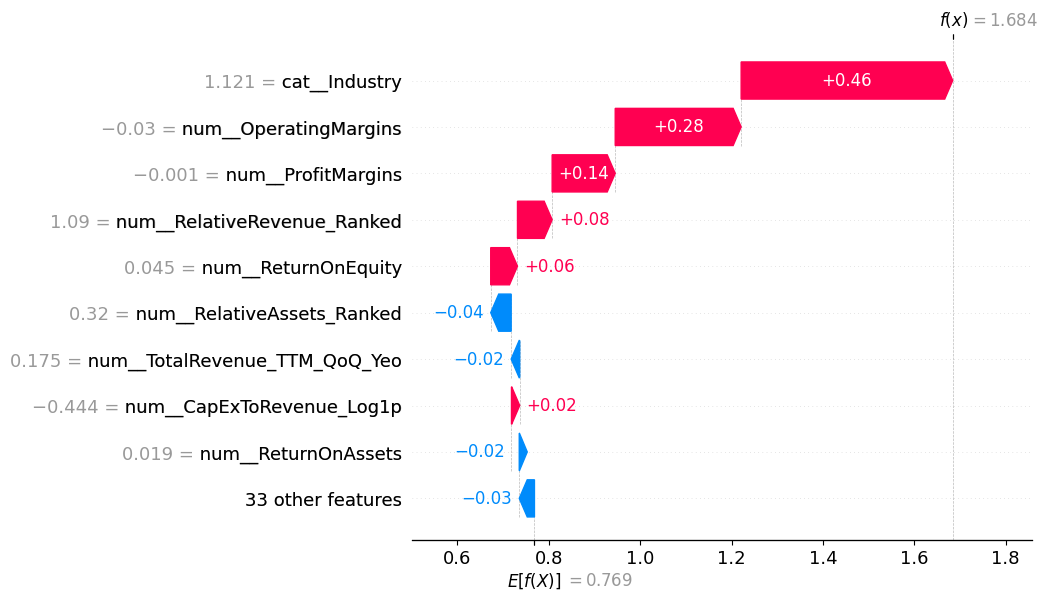

In [15]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [13]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)